In [2]:
pip install kagglehub


   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   -------------------- ------------------- 1/2 [kagglehub]
   -------------------- ------------------- 1/2 [kagglehub]
   ---------------------------------------- 2/2 [kagglehub]

Note: you may need to restart the kernel to use updated packages.


In [4]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("sergionefedov/oil-and-geopolitics-9k-daily-obs-brent-35-years")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\Zenil\.cache\kagglehub\datasets\sergionefedov\oil-and-geopolitics-9k-daily-obs-brent-35-years\versions\1


In [5]:
import os
files = os.listdir(path)
print(files)

['geopolitical_events.csv', 'iran_oil_exports.csv', 'oil_prices_daily.csv', 'risk_indicators.csv', 'sanctions_timeline.csv']


In [6]:
import pandas as pd

In [10]:
geo = pd.read_csv(os.path.join(path, "geopolitical_events.csv"))
oil = pd.read_csv(os.path.join(path, "iran_oil_exports.csv"))
risk = pd.read_csv(os.path.join(path, "risk_indicators.csv"))
sanctions = pd.read_csv(os.path.join(path, "sanctions_timeline.csv"))

In [11]:
geo["region"].value_counts()

region
Middle East    45
Global         23
Name: count, dtype: int64

In [15]:
geo

,date,event_name,event_type,region,iran_involved,price_shock_pct,shock_direction,duration_days,severity,strait_of_hormuz_risk,sanctions_related,military_action
0,1990-08-02,Iraq invades Kuwait,military,Middle East,0,28.0,up,90,extreme,0,0,1
1,1991-01-17,Gulf War begins (Operation Desert Storm),military,Middle East,0,-15.0,down,30,high,0,0,1
2,1991-02-28,Gulf War ceasefire,diplomatic,Middle East,0,-12.0,down,14,high,0,0,0
3,1998-12-16,Operation Desert Fox (Iraq bombing),military,Middle East,0,8.0,up,7,medium,0,0,1
4,2001-09-11,9/11 attacks,terror,Global,0,12.0,up,30,extreme,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
63,2024-10-01,Iran fires ballistic missiles at Israel,military,Middle East,1,5.0,up,14,high,0,0,1
64,2024-10-26,Israel strikes Iran military sites,military,Middle East,1,3.0,up,7,high,0,0,1
65,2025-04-01,Iran-Israel escalation new round,military,Middle East,1,6.0,up,21,high,0,0,1
66,2025-04-12,US strikes Houthi targets (major op),military,Middle East,0,4.0,up,14,high,1,0,1


In [20]:
pd.crosstab(geo["event_type"], geo["region"])

region,Global,Middle East
event_type,,
diplomatic,1,6
economic,1,0
market,10,4
military,3,22
political,3,6
sanctions,3,7
terror,2,0


In [21]:
# Quick look at each dataset
for df, name in [(geo, "Geopolitical Events"), 
                 (oil, "Iran Oil Exports"), 
                 (risk, "Risk Indicators"), 
                 (sanctions, "Sanctions Timeline")]:
    print(f"\n{name} Dataset:")
    print(df.info())
    print(df.head(3))


Geopolitical Events Dataset:
<class 'pandas.DataFrame'>
RangeIndex: 68 entries, 0 to 67
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   date                   68 non-null     str    
 1   event_name             68 non-null     str    
 2   event_type             68 non-null     str    
 3   region                 68 non-null     str    
 4   iran_involved          68 non-null     int64  
 5   price_shock_pct        68 non-null     float64
 6   shock_direction        68 non-null     str    
 7   duration_days          68 non-null     int64  
 8   severity               68 non-null     str    
 9   strait_of_hormuz_risk  68 non-null     int64  
 10  sanctions_related      68 non-null     int64  
 11  military_action        68 non-null     int64  
dtypes: float64(1), int64(5), str(6)
memory usage: 10.8 KB
None
         date                                event_name  event_type  \
0  1990-08-02  

In [22]:
# Summary stats
print(geo.describe(include="all"))
print(oil.describe())
print(risk.describe())
print(sanctions.describe())

              date           event_name event_type       region  \
count           68                   68         68           68   
unique          68                   68          7            2   
top     1990-08-02  Iraq invades Kuwait   military  Middle East   
freq             1                    1         25           45   
mean           NaN                  NaN        NaN          NaN   
std            NaN                  NaN        NaN          NaN   
min            NaN                  NaN        NaN          NaN   
25%            NaN                  NaN        NaN          NaN   
50%            NaN                  NaN        NaN          NaN   
75%            NaN                  NaN        NaN          NaN   
max            NaN                  NaN        NaN          NaN   

        iran_involved  price_shock_pct shock_direction  duration_days  \
count       68.000000        68.000000              68      68.000000   
unique            NaN              NaN           

In [30]:
sanctions["date"]

0     1979-11-14
1     1987-10-29
2     1995-05-06
3     1996-08-05
4     2006-12-23
5     2007-03-24
6     2008-03-03
7     2010-06-09
8     2010-07-01
9     2012-01-23
10    2012-07-01
11    2012-08-10
12    2013-11-24
13    2015-07-14
14    2016-01-16
15    2018-05-08
16    2018-08-06
17    2018-11-05
18    2019-04-22
19    2019-06-24
20    2020-09-19
21    2021-01-20
22    2022-02-01
23    2024-04-18
24    2025-04-20
Name: date, dtype: str

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns

In [36]:
geo

,date,event_name,event_type,region,iran_involved,price_shock_pct,shock_direction,duration_days,severity,strait_of_hormuz_risk,sanctions_related,military_action
0,1990-08-02,Iraq invades Kuwait,military,Middle East,0,28.0,up,90,extreme,0,0,1
1,1991-01-17,Gulf War begins (Operation Desert Storm),military,Middle East,0,-15.0,down,30,high,0,0,1
2,1991-02-28,Gulf War ceasefire,diplomatic,Middle East,0,-12.0,down,14,high,0,0,0
3,1998-12-16,Operation Desert Fox (Iraq bombing),military,Middle East,0,8.0,up,7,medium,0,0,1
4,2001-09-11,9/11 attacks,terror,Global,0,12.0,up,30,extreme,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
63,2024-10-01,Iran fires ballistic missiles at Israel,military,Middle East,1,5.0,up,14,high,0,0,1
64,2024-10-26,Israel strikes Iran military sites,military,Middle East,1,3.0,up,7,high,0,0,1
65,2025-04-01,Iran-Israel escalation new round,military,Middle East,1,6.0,up,21,high,0,0,1
66,2025-04-12,US strikes Houthi targets (major op),military,Middle East,0,4.0,up,14,high,1,0,1


In [37]:
pd.crosstab(geo["event_type"], geo["severity"])

severity,extreme,high,low,medium
event_type,,,,
diplomatic,0,2,2,3
economic,1,0,0,0
market,4,7,0,3
military,5,10,1,9
political,0,3,1,5
sanctions,0,5,0,5
terror,1,1,0,0


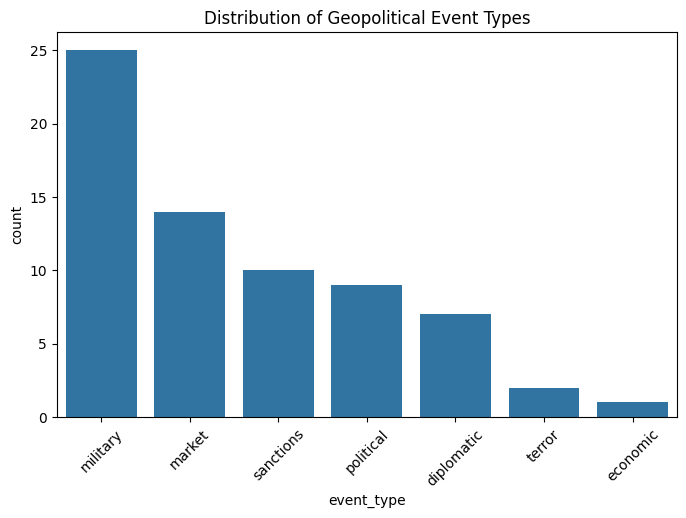

In [38]:
plt.figure(figsize=(8,5))
sns.countplot(data=geo, x="event_type", order=geo["event_type"].value_counts().index)
plt.title("Distribution of Geopolitical Event Types")
plt.xticks(rotation=45)
plt.show()

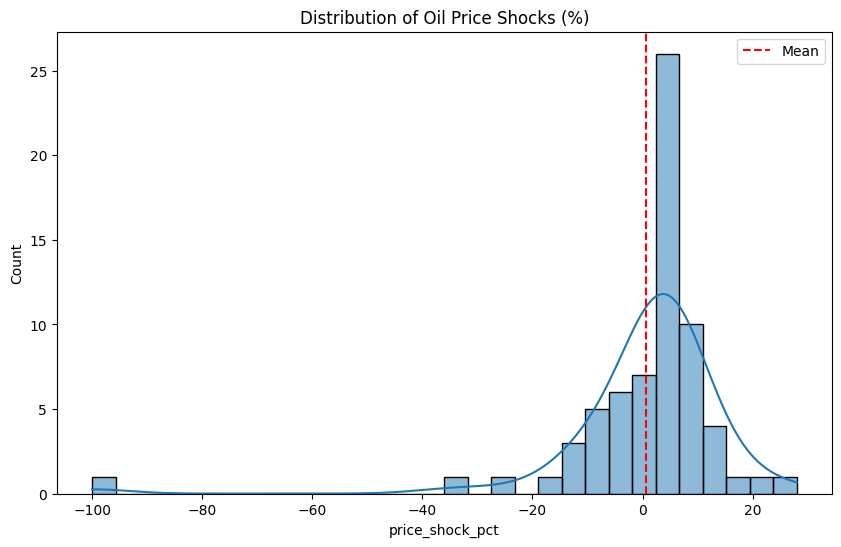

In [39]:
plt.figure(figsize=(10,6))
sns.histplot(geo["price_shock_pct"], bins=30, kde=True)
plt.title("Distribution of Oil Price Shocks (%)")
plt.axvline(geo["price_shock_pct"].mean(), color="red", linestyle="--", label="Mean")
plt.legend()
plt.show()

### Inference from above chart

1. Most shocks are small and cluster near zero
- The bulk of events caused only modest changes in oil prices (±5–10%).
- This suggests that while geopolitical events are frequent, markets often absorb them without dramatic swings.
  
2. Distribution is skewed
- The curve shows a slight skew toward negative shocks, meaning downward price moves (drops) are more common than upward surges.
- However, the mean (red dashed line) sits just above zero, indicating that overall shocks balance out with a slight upward bias.
  
3. Rare but extreme events dominate tails
- The -100% shock (April 2020 WTI crash) is a clear outlier, far beyond normal volatility.
- Large positive shocks (e.g., +28% during Iraq’s invasion of Kuwait in 1990) are rare but impactful.


### Distribution of Event Types

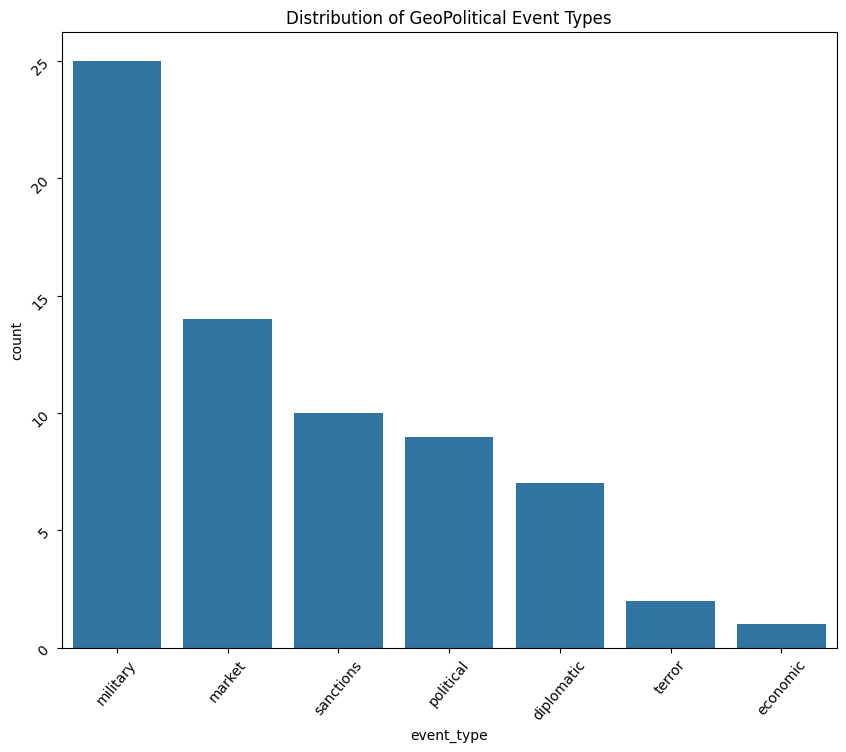

In [45]:
plt.figure(figsize=(10,8))
sns.countplot(data=geo, x="event_type", order=geo["event_type"].value_counts().index)
plt.title("Distribution of GeoPolitical Event Types")
plt.xticks(rotation=50)
plt.yticks(rotation=45)
plt.show()

<Axes: xlabel='event_type', ylabel='price_shock_pct'>

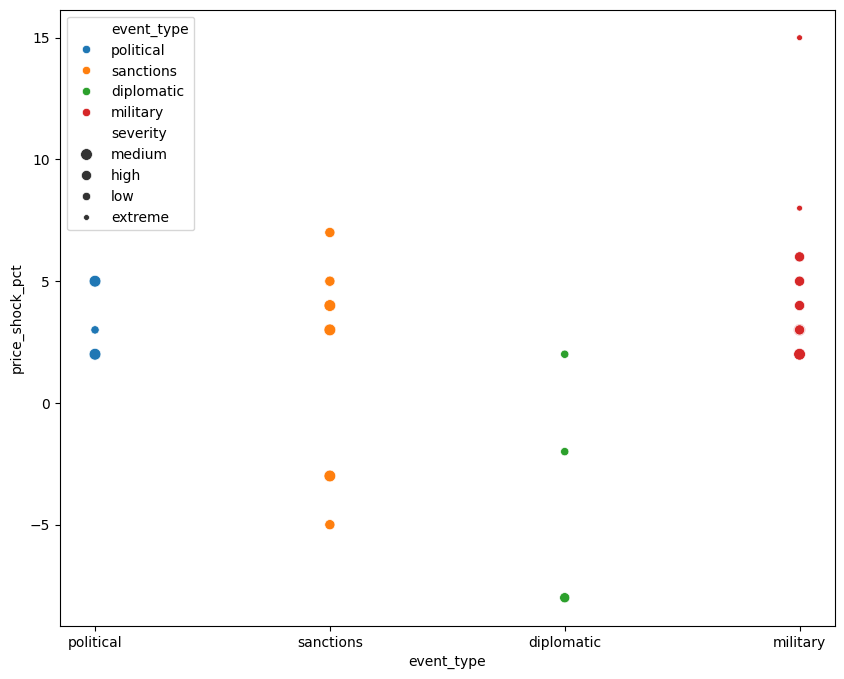

In [50]:
iran_events = geo[geo["iran_involved"]==1]

plt.figure(figsize=(10,8))
sns.scatterplot(data=iran_events, x="event_type", y="price_shock_pct", hue="event_type", size="severity")

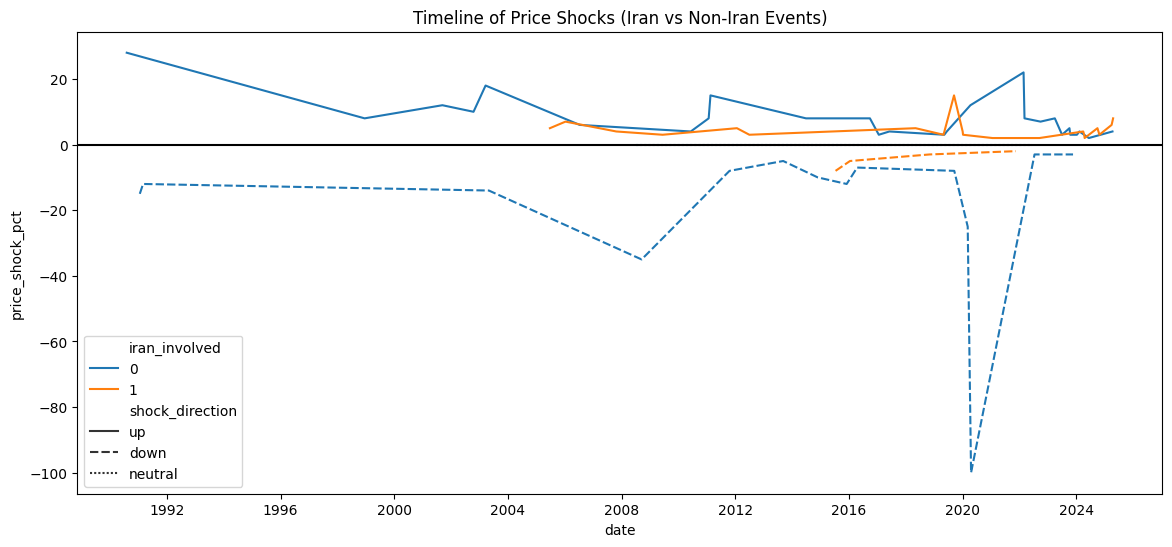

In [53]:
geo["date"] = pd.to_datetime(geo["date"])
plt.figure(figsize=(14,6))
sns.lineplot(data=geo, x="date", y="price_shock_pct", hue="iran_involved", style="shock_direction")
plt.title("Timeline of Price Shocks (Iran vs Non-Iran Events)")
plt.axhline(0, color="black", linestyle="solid")
plt.show()

In [54]:
oil

,year,destination,exports_mbd,total_iran_exports_mbd,share_pct,sanctions_status,is_sanctions_year,estimated_revenue_bn_usd
0,1990,China,0.797,2.3,34.6,none,0,13956.6
1,1990,India,0.532,2.3,23.1,none,0,9327.5
2,1990,Japan,0.278,2.3,12.1,none,0,4865.9
3,1990,South Korea,0.213,2.3,9.3,none,0,3738.2
4,1990,Italy,0.218,2.3,9.5,none,0,3826.3
...,...,...,...,...,...,...,...,...
355,2025,Turkey,0.085,1.6,5.3,none,0,1492.1
356,2025,Greece,0.058,1.6,3.7,none,0,1024.0
357,2025,Spain,0.103,1.6,6.4,none,0,1804.0
358,2025,Syria,0.019,1.6,1.2,none,0,325.4


Task was destroyed but it is pending!
task: <Task pending name='Task-331' coro=<_async_in_context.<locals>.run_in_context() done, defined at C:\Users\Zenil\AppData\Roaming\Python\Python313\site-packages\ipykernel\utils.py:57> wait_for=<Task pending name='Task-332' coro=<Kernel.shell_main() running at C:\Users\Zenil\AppData\Roaming\Python\Python313\site-packages\ipykernel\kernelbase.py:597> cb=[Task.task_wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at C:\Users\Zenil\AppData\Roaming\Python\Python313\site-packages\zmq\eventloop\zmqstream.py:563]>
C:\Users\Zenil\AppData\Local\Programs\Python\Python313\Lib\site-packages\matplotlib\transforms.py:195: RuntimeWarning: coroutine 'Kernel.shell_main' was never awaited
  ref = weakref.ref(
Task was destroyed but it is pending!
task: <Task pending name='Task-332' coro=<Kernel.shell_main() running at C:\Users\Zenil\AppData\Roaming\Python\Python313\site-packages\ipykernel\kernelbase.py:597> cb=[Task.task_wakeup()]>


<BarContainer object of 360 artists>

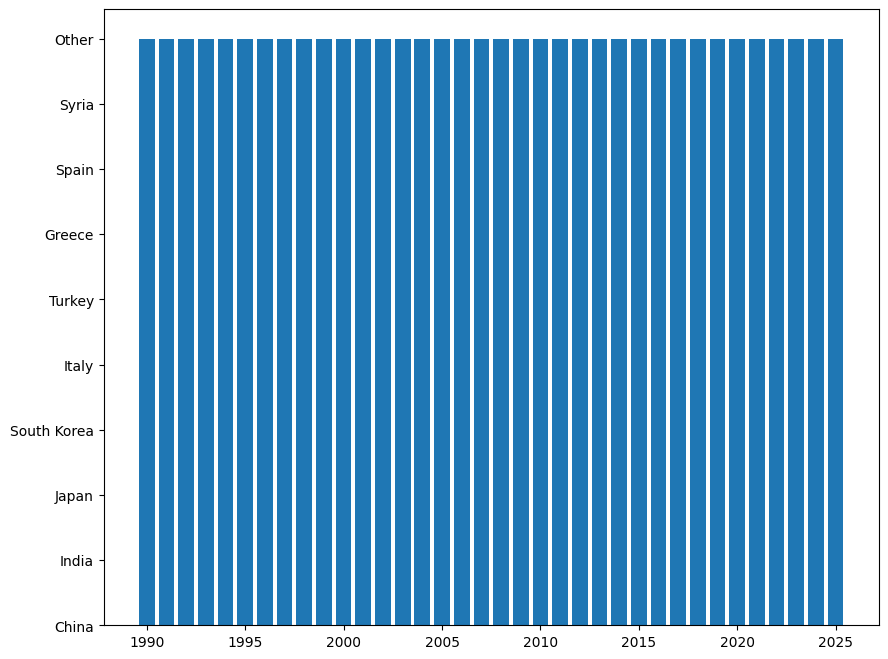

In [64]:
plt.figure(figsize=(10, 8))
plt.bar(oil["year"], oil["destination"])
    

